In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_PATH = Path("bbc-text.csv")

# Download bbc-text.csv if not present
if not DATA_PATH.exists():
    url = "https://raw.githubusercontent.com/mdsohaib/BBC-News-Classification/master/bbc-text.csv"
    print("Downloading:", url)
    df = pd.read_csv(url)
    df.to_csv(DATA_PATH, index=False)
else:
    df = pd.read_csv(DATA_PATH)

print(df.head())
print("rows:", len(df), "cols:", list(df.columns))
print(df["category"].value_counts())


        category                                               text
0           tech  tv future in the hands of viewers with home th...
1       business  worldcom boss  left books alone  former worldc...
2          sport  tigers wary of farrell  gamble  leicester say ...
3          sport  yeading face newcastle in fa cup premiership s...
4  entertainment  ocean s twelve raids box office ocean s twelve...
rows: 2225 cols: ['category', 'text']
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [4]:
import re
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Basic cleaning

def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z\s]", " ", s)  # keep letters/spaces
    s = re.sub(r"\s+", " ", s).strip()
    return s

texts = df["text"].astype(str).map(clean_text).tolist()
labels = df["category"].astype(str).tolist()

# Encode labels to ints
label_to_id = {name: i for i, name in enumerate(sorted(set(labels)))}
id_to_label = {i: name for name, i in label_to_id.items()}
y = np.array([label_to_id[l] for l in labels], dtype=np.int32)
num_classes = len(label_to_id)

print("classes:", label_to_id)

# Train/test split (stratified)
from sklearn.model_selection import train_test_split

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Tokenize
VOCAB_SIZE = 20000
OOV_TOKEN = "<OOV>"

tok = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tok.fit_on_texts(X_train_txt)

train_seq = tok.texts_to_sequences(X_train_txt)
test_seq = tok.texts_to_sequences(X_test_txt)

# Pad
MAX_LEN = 250
train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("train_pad:", train_pad.shape, "test_pad:", test_pad.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# Check class distribution first
print("\nTrain class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")


classes: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}
train_pad: (1780, 250) test_pad: (445, 250)
y_train: (1780,) y_test: (445,)

Train class distribution:
  business: 408
  entertainment: 309
  politics: 333
  sport: 409
  tech: 321


In [5]:
from tensorflow.keras import layers

# Improved parameters
VOCAB_SIZE = 20000
EMBED_DIM = 256        # increased from 128
LSTM_UNITS = 256       # increased from 128
MAX_LEN = 500          # increased from 250 — BBC articles are long
DROPOUT = 0.3

# Re-pad with new MAX_LEN
train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

# Improved Bidirectional LSTM model
model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=0.2)),
    layers.Bidirectional(layers.LSTM(128, dropout=0.2)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 256)       │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 500, 256)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 500, 512)       │     1,050,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,868,485 (26.20 MB)

 Trainable params: 6,868,485 (26.20 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Improved training
BATCH_SIZE = 32        # reduced from 64 for better generalization
EPOCHS = 20

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=2,
        verbose=1,
        min_lr=1e-6
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    train_pad,
    y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 181s 3s/step - accuracy: 0.2884 - loss: 1.5839 - val_accuracy: 0.2022 - val_loss: 2.0333 - learning_rate: 0.0010
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 335s 7s/step - accuracy: 0.4388 - loss: 1.2788 - val_accuracy: 0.7247 - val_loss: 0.7557 - learning_rate: 0.0010
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 340s 7s/step - accuracy: 0.8652 - loss: 0.4528 - val_accuracy: 0.9213 - val_loss: 0.2769 - learning_rate: 0.0010
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 218s 4s/step - accuracy: 0.9744 - loss: 0.1254 - val_accuracy: 0.9101 - val_loss: 0.2778 - learning_rate: 0.0010
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step - accuracy: 0.9844 - loss: 0.0666 - val_accuracy: 0.9270 - val_loss: 0.2372 - learning_rate: 0.0010
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - accuracy: 0.9963 - loss: 0.0244 - val_accuracy: 0.9045 - val_loss: 0.4132 - learning_rate: 0.0010
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 225s 4s/step - accuracy: 0.9956 - loss: 0.0256 - val_acc

In [7]:
# Evaluate: loss/accuracy
loss, acc = model.evaluate(test_pad, y_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {acc*100:.2f}%")

# Confusion matrix + Precision/Recall/F1
from sklearn.metrics import confusion_matrix, classification_report

y_prob = model.predict(test_pad, batch_size=256, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

a = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=true, cols=pred):\n", a)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=[id_to_label[i] for i in range(num_classes)], digits=4))


Test loss: 0.4814
Test accuracy: 91.69%
Confusion matrix (rows=true, cols=pred):
 [[91  6  3  1  1]
 [ 1 73  0  1  2]
 [ 3  3 75  1  2]
 [ 1  2  3 96  0]
 [ 2  5  0  0 73]]

Classification report:
               precision    recall  f1-score   support

     business     0.9286    0.8922    0.9100       102
entertainment     0.8202    0.9481    0.8795        77
     politics     0.9259    0.8929    0.9091        84
        sport     0.9697    0.9412    0.9552       102
         tech     0.9359    0.9125    0.9241        80

     accuracy                         0.9169       445
    macro avg     0.9161    0.9173    0.9156       445
 weighted avg     0.9201    0.9169    0.9174       445



## Compare with paper (Ezen‑Can, Springer 2023)

Paper target accuracy: **97.0%**

After training, fill in your achieved accuracy from the evaluation cell:

- Paper: **97.0%**
- Yours: **(acc * 100)%**

### Why your accuracy may differ

Common reasons your result can be below 97%:

- **Train/test split differences**: paper may use a specific split or cross‑validation; you’re using an 80/20 stratified split.
- **Preprocessing differences**: tokenization, max length, vocab size, stopword removal, etc.
- **Hyperparameters**: embedding dim, LSTM units, dropout, batch size, LR schedule.
- **Model details**: biLSTM, stacked LSTM, attention, pre-trained embeddings can improve results.
- **Randomness**: different seeds and library versions shift results slightly.


In [8]:
# Improved pipeline: TextVectorization + BiLSTM (typically much higher accuracy on BBC)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)

MAX_TOKENS = 30000
SEQ_LEN = 400

vectorize = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN,
    standardize="lower_and_strip_punctuation",
)

# Adapt on training text only
vectorize.adapt(tf.data.Dataset.from_tensor_slices(X_train_txt).batch(64))

BATCH_SIZE = 64

def make_ds(texts, labels, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(texts), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).map(lambda t, y: (vectorize(t), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_train_txt, y_train, training=True)
test_ds = make_ds(X_test_txt, y_test, training=False)

# Keep a validation split from training
val_frac = 0.1
val_size = int(len(X_train_txt) * val_frac)

val_ds = make_ds(X_train_txt[:val_size], y_train[:val_size], training=False)
train_ds2 = make_ds(X_train_txt[val_size:], y_train[val_size:], training=True)

print("train/val/test sizes:", len(X_train_txt[val_size:]), val_size, len(X_test_txt))


train/val/test sizes: 1602 178 445


In [9]:
# Improved BiLSTM model
EMBED_DIM = 128

model2 = keras.Sequential([
    layers.Input(shape=(SEQ_LEN,)),
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.GlobalMaxPooling1D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax"),
])

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 400, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 400, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,136,709 (15.78 MB)

 Trainable params: 4,136,709 (15.78 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train improved model
EPOCHS = 15  # 10–20

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=2, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1),
]

history2 = model2.fit(
    train_ds2,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 615ms/step - accuracy: 0.2628 - loss: 1.5689 - val_accuracy: 0.4663 - val_loss: 1.4972 - learning_rate: 0.0010
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 567ms/step - accuracy: 0.4357 - loss: 1.3647 - val_accuracy: 0.4438 - val_loss: 1.1573 - learning_rate: 0.0010
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 575ms/step - accuracy: 0.6298 - loss: 0.9107 - val_accuracy: 0.8820 - val_loss: 0.5755 - learning_rate: 0.0010
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 584ms/step - accuracy: 0.8727 - loss: 0.4295 - val_accuracy: 0.8933 - val_loss: 0.3385 - learning_rate: 0.0010
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 575ms/step - accuracy: 0.9544 - loss: 0.1787 - val_accuracy: 0.9438 - val_loss: 0.1390 - learning_rate: 0.0010
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 589ms/step - accuracy: 0.9894 - loss: 0.0567 - val_accuracy: 0.9607 - val_loss: 0.1225 - learning_rate: 0.0010
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 590ms/step - accuracy: 0.9956 - loss: 0.

In [11]:
# Evaluate improved model
loss2, acc2 = model2.evaluate(test_ds, verbose=0)
print(f"Improved Test loss: {loss2:.4f}")
print(f"Improved Test accuracy: {acc2*100:.2f}%")

# Confusion matrix + Precision/Recall/F1
from sklearn.metrics import confusion_matrix, classification_report

y_prob2 = model2.predict(test_ds, verbose=0)
y_pred2 = np.argmax(y_prob2, axis=1)

cm2 = confusion_matrix(y_test, y_pred2)
print("Confusion matrix (rows=true, cols=pred):\n", cm2)

print("\nClassification report:")
print(classification_report(y_test, y_pred2, target_names=[id_to_label[i] for i in range(num_classes)], digits=4))


Improved Test loss: 0.1238
Improved Test accuracy: 95.73%
Confusion matrix (rows=true, cols=pred):
 [[ 95   3   4   0   0]
 [  0  75   1   1   0]
 [  1   3  78   0   2]
 [  0   1   0 101   0]
 [  1   2   0   0  77]]

Classification report:
               precision    recall  f1-score   support

     business     0.9794    0.9314    0.9548       102
entertainment     0.8929    0.9740    0.9317        77
     politics     0.9398    0.9286    0.9341        84
        sport     0.9902    0.9902    0.9902       102
         tech     0.9747    0.9625    0.9686        80

     accuracy                         0.9573       445
    macro avg     0.9554    0.9573    0.9559       445
 weighted avg     0.9586    0.9573    0.9575       445



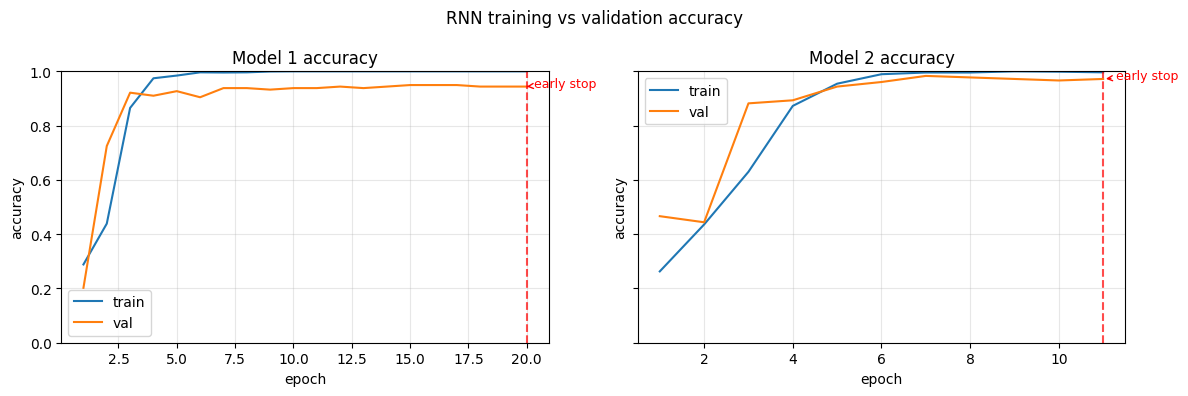

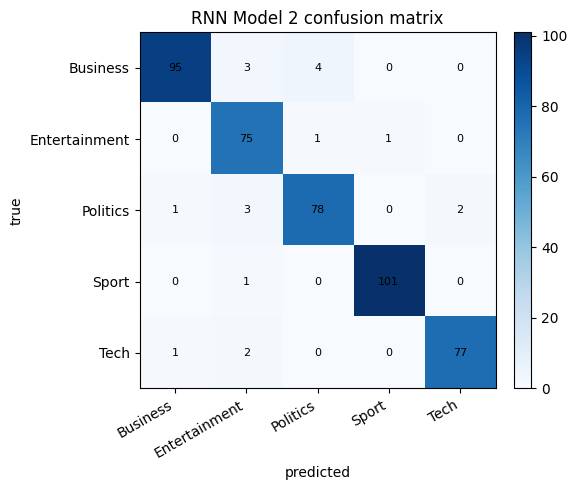

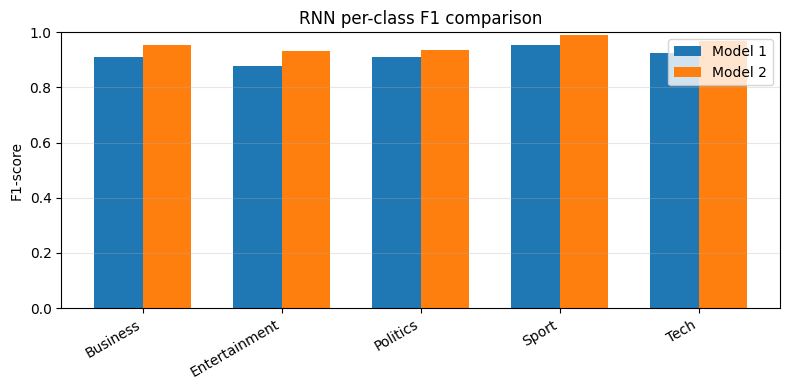

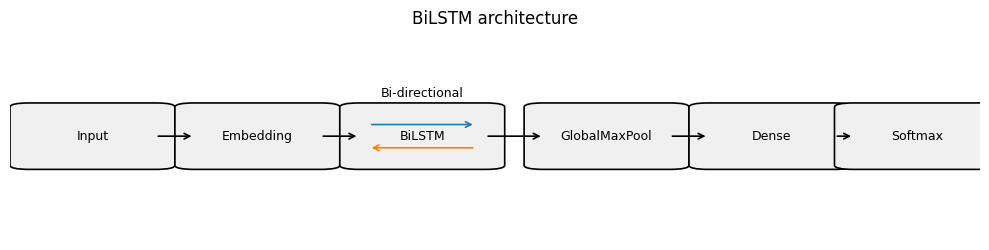

In [12]:
# Section 8 diagrams: RNN
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

if "history" not in globals() or "history2" not in globals():
    raise RuntimeError("Run the training cells to create history and history2 before plotting.")


def plot_history(ax, hist, title):
    acc = hist.history.get("accuracy", [])
    val_acc = hist.history.get("val_accuracy", [])
    epochs = np.arange(1, len(acc) + 1)
    ax.plot(epochs, acc, label="train")
    if len(val_acc) == len(acc) and len(val_acc) > 0:
        ax.plot(epochs, val_acc, label="val")
        y_last = val_acc[-1]
    else:
        y_last = acc[-1] if len(acc) > 0 else 0
    es_epoch = len(acc)
    if es_epoch > 0:
        ax.axvline(es_epoch, color="red", linestyle="--", alpha=0.7)
        ax.annotate(
            "early stop",
            xy=(es_epoch, y_last),
            xytext=(es_epoch + 0.3, y_last),
            fontsize=9,
            color="red",
            arrowprops={"arrowstyle": "->", "color": "red"},
        )
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_history(axes[0], history, "Model 1 accuracy")
plot_history(axes[1], history2, "Model 2 accuracy")
fig.suptitle("RNN training vs validation accuracy")
plt.tight_layout()
plt.show()

# Confusion matrix heatmap (Model 2)
label_names = [id_to_label[i] for i in range(num_classes)]
label_names_title = [name.title() for name in label_names]

y_prob2 = model2.predict(test_ds, verbose=0)
y_pred2 = np.argmax(y_prob2, axis=1)
cm2 = confusion_matrix(y_test, y_pred2)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm2, cmap="Blues")
ax.set_title("RNN Model 2 confusion matrix")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(label_names_title, rotation=30, ha="right")
ax.set_yticklabels(label_names_title)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        ax.text(j, i, str(cm2[i, j]), ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Per-class F1 comparison (Model 1 vs Model 2)
y_prob1 = model.predict(test_pad, batch_size=256, verbose=0)
y_pred1 = np.argmax(y_prob1, axis=1)

report1 = classification_report(
    y_test, y_pred1, target_names=label_names, output_dict=True, digits=4
)
report2 = classification_report(
    y_test, y_pred2, target_names=label_names, output_dict=True, digits=4
)

f1_1 = [report1[name]["f1-score"] for name in label_names]
f1_2 = [report2[name]["f1-score"] for name in label_names]

x = np.arange(len(label_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, f1_1, width, label="Model 1")
ax.bar(x + width / 2, f1_2, width, label="Model 2")
ax.set_title("RNN per-class F1 comparison")
ax.set_xticks(x)
ax.set_xticklabels(label_names_title, rotation=30, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1-score")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Architecture diagram: BiLSTM
def add_box(ax, xy, text, width=0.13, height=0.28):
    box = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.02",
        linewidth=1.2,
        edgecolor="black",
        facecolor="#f0f0f0",
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=9,
    )


fig, ax = plt.subplots(figsize=(10, 2.6))
ax.axis("off")
y = 0.36
w = 0.13
h = 0.28
x_positions = [0.02, 0.19, 0.36, 0.55, 0.72, 0.87]
labels = ["Input", "Embedding", "BiLSTM", "GlobalMaxPool", "Dense", "Softmax"]

for x_pos, label in zip(x_positions, labels):
    add_box(ax, (x_pos, y), label, width=w, height=h)

for i in range(len(x_positions) - 1):
    ax.annotate(
        "",
        xy=(x_positions[i + 1], y + h / 2),
        xytext=(x_positions[i] + w, y + h / 2),
        arrowprops={"arrowstyle": "->", "lw": 1.2},
    )

bix = x_positions[2]
ax.annotate(
    "",
    xy=(bix + w - 0.01, y + h * 0.7),
    xytext=(bix + 0.01, y + h * 0.7),
    arrowprops={"arrowstyle": "->", "lw": 1.2, "color": "#1f77b4"},
)
ax.annotate(
    "",
    xy=(bix + 0.01, y + h * 0.3),
    xytext=(bix + w - 0.01, y + h * 0.3),
    arrowprops={"arrowstyle": "->", "lw": 1.2, "color": "#ff7f0e"},
)
ax.text(bix + w / 2, y + h + 0.05, "Bi-directional", ha="center", fontsize=9)

ax.set_title("BiLSTM architecture")
plt.tight_layout()
plt.show()
